# Task 03：表格型 RL——学习与实验入口

## 本 Notebook 的学习边界

环境模型未知时，价值通过样本而不是完整转移表学习。MC 使用完整回报：

$$
G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots,
$$

TD(0) 使用一步 bootstrap：

$$
V(S_t)\leftarrow V(S_t)+lpha\left[R_{t+1}+\gamma V(S_{t+1})-V(S_t)ight].
$$

本 Notebook 的第一部分检查 prediction，第二部分比较 DP、MC、TD 以及 SARSA/Q-Learning；重点观察“是否 bootstrap”和“目标策略是否等于行为策略”。


## 1. Monte Carlo vs TD(0): Update Mechanism

Monte Carlo 和 TD(0) 都属于 model-free prediction，目标都是在固定策略 $\pi$ 下估计：

$$
V_\pi(s)
$$

二者的核心区别在于更新目标：

Monte Carlo 使用完整回报：

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$

$$
V(S_t) \leftarrow V(S_t) + \alpha [G_t - V(S_t)]
$$

因此必须等待 episode 结束。

TD(0) 使用一步 bootstrap target：

$$
R_{t+1} + \gamma V(S_{t+1})
$$

$$
V(S_t) \leftarrow V(S_t)
+ \alpha
[R_{t+1}+\gamma V(S_{t+1})-V(S_t)]
$$

因此每与环境交互一步即可更新。

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import random

from src.gridworld import GridWorld
from src.monte_carlo import generate_episode


random.seed(42)

env = GridWorld()
gamma = 1.0


def random_policy(state):
    return random.choice([0, 1, 2, 3])


# ============================================================
# 1. Generate one complete episode
# ============================================================

episode = generate_episode(
    env=env,
    policy=random_policy,
)

print(f"Episode length: {len(episode)}")


# ============================================================
# 2. Monte Carlo: calculate complete return G_t
# ============================================================

mc_returns = [0.0] * len(episode)

G = 0.0

for t in reversed(range(len(episode))):
    _, _, reward = episode[t]

    G = reward + gamma * G
    mc_returns[t] = G


# ============================================================
# 3. TD(0): calculate one-step target
#
# Here V(s)=0 initially, only to illustrate the update target.
# ============================================================

V = {
    state: 0.0
    for state in env.get_states()
}

td_targets = []

for state, action, reward in episode:

    # We do not store next_state in episode, so for illustration:
    # next state's V is initially 0.
    td_target = reward

    td_targets.append(td_target)


# ============================================================
# 4. Compare MC target and TD target
# ============================================================

print(
    f"\n{'t':>3} "
    f"{'State':>10} "
    f"{'Reward':>8} "
    f"{'MC Target G_t':>14} "
    f"{'TD Target':>12}"
)

print("-" * 55)

for t, ((state, action, reward), G, td_target) in enumerate(
    zip(episode, mc_returns, td_targets)
):
    print(
        f"{t:3d} "
        f"{str(state):>10} "
        f"{reward:8.1f} "
        f"{G:14.1f} "
        f"{td_target:12.1f}"
    )

Episode length: 81

  t      State   Reward  MC Target G_t    TD Target
-------------------------------------------------------
  0     (0, 0)     -1.0          -70.0         -1.0
  1     (0, 0)     -1.0          -69.0         -1.0
  2     (0, 0)     -1.0          -68.0         -1.0
  3     (0, 0)     -1.0          -67.0         -1.0
  4     (1, 0)     -1.0          -66.0         -1.0
  5     (2, 0)     -1.0          -65.0         -1.0
  6     (3, 0)     -1.0          -64.0         -1.0
  7     (2, 0)     -1.0          -63.0         -1.0
  8     (1, 0)     -1.0          -62.0         -1.0
  9     (1, 0)     -1.0          -61.0         -1.0
 10     (0, 0)     -1.0          -60.0         -1.0
 11     (0, 0)     -1.0          -59.0         -1.0
 12     (0, 0)     -1.0          -58.0         -1.0
 13     (1, 0)     -1.0          -57.0         -1.0
 14     (2, 0)     -1.0          -56.0         -1.0
 15     (1, 0)     -1.0          -55.0         -1.0
 16     (2, 0)     -1.0          -54.0  

## 2. Fixed-Policy Evaluation: DP vs MC vs TD

这一实验在相同的均匀随机策略下比较三种策略评估方法：

$$
\pi(a|s)=\frac{1}{|\mathcal A|}
$$

三种方法的目标完全相同，都是估计：

$$
V_\pi(s)
$$

区别只在于价值信息的来源：

- **DP**：已知环境模型，通过 Bellman expectation equation 直接计算；
- **MC**：不知道环境模型，通过完整 episode 的 return $G_t$ 进行估计；
- **TD(0)**：不知道环境模型，通过一步真实采样和 bootstrap 进行估计。

因此 DP 的结果可以作为 reference，用于观察 MC 和 TD 是否能够仅依靠环境交互逼近相同的 $V_\pi$。

In [2]:
import random
import numpy as np

from src.gridworld import GridWorld
from src.monte_carlo import first_visit_mc_prediction
from src.td_learning import td0_prediction

# 按 Task 02 中实际的文件路径修改这一行
from src.policy_evaluation import policy_evaluation


SEED = 42
GAMMA = 1.0
ACTIONS = [0, 1, 2, 3]

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# 1. Same fixed policy π for all three methods
# ============================================================

def random_policy(state):
    """Used by MC / TD to actually sample one action."""
    return random.choice(ACTIONS)


# DP needs the probability distribution π(a|s)
def uniform_policy(state):
    return {
        action: 1.0 / len(ACTIONS)
        for action in ACTIONS
    }


# ============================================================
# 2. DP: model-based reference
# ============================================================

env_dp = GridWorld()

V_dp = policy_evaluation(
    env=env_dp,
    policy=uniform_policy,
    gamma=GAMMA,
)


# ============================================================
# 3. Monte Carlo: complete-return sampling
# ============================================================

random.seed(SEED)

env_mc = GridWorld()

V_mc = first_visit_mc_prediction(
    env=env_mc,
    policy=random_policy,
    num_episodes=10_000,
    gamma=GAMMA,
)


# ============================================================
# 4. TD(0): one-step bootstrap
# ============================================================

random.seed(SEED)

env_td = GridWorld()

V_td = td0_prediction(
    env=env_td,
    policy=random_policy,
    num_episodes=100_000,
    alpha=0.01,
    gamma=GAMMA,
)


# ============================================================
# 5. Compare Vπ
# ============================================================

common_states = sorted(
    set(V_dp)
    & set(V_mc)
    & set(V_td)
)

print(
    f"{'State':>10}"
    f"{'DP':>12}"
    f"{'MC':>12}"
    f"{'TD':>12}"
)

print("-" * 46)

for state in common_states:
    print(
        f"{str(state):>10}"
        f"{V_dp[state]:12.4f}"
        f"{V_mc[state]:12.4f}"
        f"{V_td[state]:12.4f}"
    )


# ============================================================
# 6. Error relative to DP reference
# ============================================================

mc_rmse = np.sqrt(
    np.mean([
        (V_mc[s] - V_dp[s]) ** 2
        for s in common_states
    ])
)

td_rmse = np.sqrt(
    np.mean([
        (V_td[s] - V_dp[s]) ** 2
        for s in common_states
    ])
)

print("\nRMSE against DP reference")
print(f"MC : {mc_rmse:.4f}")
print(f"TD : {td_rmse:.4f}")

     State          DP          MC          TD
----------------------------------------------
    (0, 0)    -49.4000    -50.1312    -48.0352
    (0, 1)    -47.4000    -48.1965    -46.4416
    (0, 2)    -41.4000    -42.5903    -40.2941
    (0, 3)    -38.3333    -38.9620    -37.2090
    (1, 0)    -47.4000    -48.3610    -45.4625
    (1, 2)    -34.4666    -35.0262    -32.8173
    (1, 3)    -31.2666    -31.9599    -29.3871
    (2, 0)    -41.4000    -42.5489    -40.1395
    (2, 1)    -34.4666    -35.2532    -33.0458
    (2, 2)    -26.7333    -27.4253    -25.7879
    (2, 3)    -17.0000    -17.4588    -15.9487
    (3, 0)    -38.3333    -39.6952    -37.8274
    (3, 1)    -31.2666    -31.9438    -30.5030
    (3, 2)    -17.0000    -17.8625    -18.2896
    (3, 3)      0.0000      0.0000      0.0000

RMSE against DP reference
MC : 0.8320
TD : 1.2486


## 3. Convergence: MC vs TD

上一节比较了训练结束后的最终价值估计，本节进一步观察 MC 和 TD 的学习过程。

仍然使用相同的固定随机策略 $\pi$，并将 DP 得到的 $V_\pi$ 作为 reference。

定义价值估计误差：

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{|\mathcal S|}
\sum_{s\in\mathcal S}
\left(
V(s)-V_\pi^{DP}(s)
\right)^2
}
$$

随着采样 episode 数增加：

- MC 通过更多完整 return 样本逼近 $V_\pi$；
- TD 通过不断进行一步 bootstrap 更新逼近 $V_\pi$。

需要注意：由于两者都是 sampling-based 方法，误差曲线不要求严格单调下降。

  Episodes     MC RMSE     TD RMSE
----------------------------------
       100      6.9251     31.6016
       500      1.9759     22.6591
      1000      1.1936     15.0203
      5000      0.3359      0.8158
     10000      0.8320      1.4465
     50000      0.3473      1.7258
    100000      0.1770      1.2486


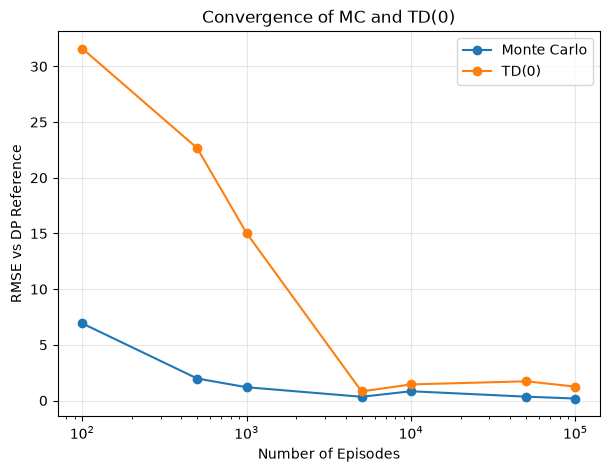

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt


episode_counts = [
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
]

mc_rmse_history = []
td_rmse_history = []

for n in episode_counts:

    # ==================== MC ====================
    random.seed(SEED)
    np.random.seed(SEED)

    env_mc = GridWorld()

    V_mc_n = first_visit_mc_prediction(
        env=env_mc,
        policy=random_policy,
        num_episodes=n,
        gamma=GAMMA,
    )

    mc_rmse = np.sqrt(
        np.mean([
            (V_mc_n[s] - V_dp[s]) ** 2
            for s in common_states
        ])
    )

    mc_rmse_history.append(mc_rmse)


    # ==================== TD(0) ====================
    random.seed(SEED)
    np.random.seed(SEED)

    env_td = GridWorld()

    V_td_n = td0_prediction(
        env=env_td,
        policy=random_policy,
        num_episodes=n,
        alpha=0.01,
        gamma=GAMMA,
    )

    td_rmse = np.sqrt(
        np.mean([
            (V_td_n[s] - V_dp[s]) ** 2
            for s in common_states
        ])
    )

    td_rmse_history.append(td_rmse)


# ==================== Results ====================

print(
    f"{'Episodes':>10}"
    f"{'MC RMSE':>12}"
    f"{'TD RMSE':>12}"
)

print("-" * 34)

for n, mc_error, td_error in zip(
    episode_counts,
    mc_rmse_history,
    td_rmse_history,
):
    print(
        f"{n:10d}"
        f"{mc_error:12.4f}"
        f"{td_error:12.4f}"
    )


plt.figure(figsize=(7, 5))

plt.plot(
    episode_counts,
    mc_rmse_history,
    marker="o",
    label="Monte Carlo",
)

plt.plot(
    episode_counts,
    td_rmse_history,
    marker="o",
    label="TD(0)",
)

plt.xscale("log")

plt.xlabel("Number of Episodes")
plt.ylabel("RMSE vs DP Reference")
plt.title("Convergence of MC and TD(0)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4. Effect of Learning Rate $\alpha$ on TD(0)

TD(0) 的更新为：

$$
V(S_t)
\leftarrow
V(S_t)
+
\alpha
\left[
R_{t+1}
+\gamma V(S_{t+1})
-
V(S_t)
\right]
$$

其中学习率 $\alpha$ 控制每次 TD error 对当前价值估计的影响程度。

- 较大的 $\alpha$：价值传播更快，但训练后期波动通常更明显；
- 较小的 $\alpha$：更新更加稳定，但需要更多 episode 才能充分传播价值信息。

本实验固定训练 episode 数，仅改变 $\alpha$，观察最终价值估计相对于 DP reference 的 RMSE。

     Alpha     TD RMSE
----------------------
     0.001      0.5455
     0.005      1.2975
     0.010      1.7258
     0.050      1.5026
     0.100      2.3215
     0.200      5.1389


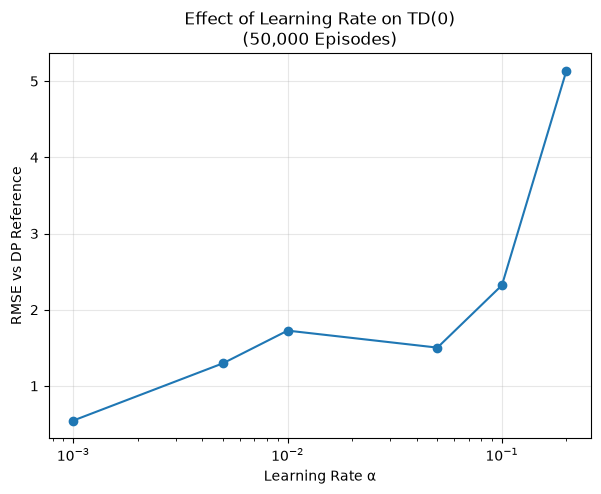

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Experiment settings
# ============================================================

alphas = [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.2,
]

num_episodes = 50_000

td_alpha_rmse = []


# ============================================================
# 2. Train TD(0) with different alpha
# ============================================================

for alpha in alphas:

    random.seed(SEED)
    np.random.seed(SEED)

    env_td = GridWorld()

    V_td_alpha = td0_prediction(
        env=env_td,
        policy=random_policy,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=GAMMA,
    )

    rmse = np.sqrt(
        np.mean([
            (V_td_alpha[s] - V_dp[s]) ** 2
            for s in common_states
        ])
    )

    td_alpha_rmse.append(rmse)


# ============================================================
# 3. Results
# ============================================================

print(
    f"{'Alpha':>10}"
    f"{'TD RMSE':>12}"
)

print("-" * 22)

for alpha, rmse in zip(
    alphas,
    td_alpha_rmse,
):
    print(
        f"{alpha:10.3f}"
        f"{rmse:12.4f}"
    )


plt.figure(figsize=(7, 5))

plt.plot(
    alphas,
    td_alpha_rmse,
    marker="o",
)

plt.xscale("log")

plt.xlabel("Learning Rate α")
plt.ylabel("RMSE vs DP Reference")
plt.title(
    f"Effect of Learning Rate on TD(0)\n"
    f"({num_episodes:,} Episodes)"
)

plt.grid(alpha=0.3)

plt.show()

## 5. SARSA vs Q-Learning: Learning Curve

SARSA 和 Q-Learning 都通过学习动作价值函数 $Q(s,a)$ 完成策略优化，但二者使用不同的 TD target。

SARSA：

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+\gamma Q(S_{t+1},A_{t+1})
-Q(S_t,A_t)
\right]
$$

其中 $A_{t+1}$ 由当前 $\varepsilon$-greedy 策略实际选择，因此 SARSA 属于 **on-policy** 方法。

Q-Learning：

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+\gamma \max_a Q(S_{t+1},a)
-Q(S_t,A_t)
\right]
$$

虽然交互时同样使用 $\varepsilon$-greedy 进行探索，但更新目标始终采用当前最优动作，因此 Q-Learning 属于 **off-policy** 方法。

本实验比较二者训练过程中 episode return 的变化。由于单个 episode 的随机性较大，使用 moving average 观察整体学习趋势。

Average return over last 100 episodes
SARSA      : 4.4900
Q-Learning : 4.3800


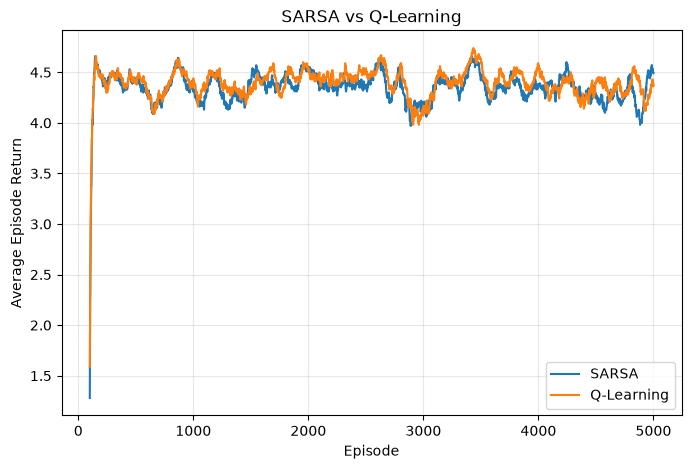

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt

from src.sarsa import sarsa
from src.q_learning import q_learning


# ============================================================
# 1. Experiment settings
# ============================================================

NUM_EPISODES = 5_000
ALPHA = 0.1
GAMMA = 1.0
EPSILON = 0.1
WINDOW = 100


def moving_average(values, window):
    values = np.asarray(values, dtype=float)

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid",
    )


# ============================================================
# 2. Train SARSA
# ============================================================

random.seed(SEED)
np.random.seed(SEED)

env_sarsa = GridWorld()

Q_sarsa, returns_sarsa = sarsa(
    env=env_sarsa,
    num_episodes=NUM_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
)


# ============================================================
# 3. Train Q-Learning
# ============================================================

random.seed(SEED)
np.random.seed(SEED)

env_q = GridWorld()

Q_q, returns_q = q_learning(
    env=env_q,
    num_episodes=NUM_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
)


# ============================================================
# 4. Moving-average learning curves
# ============================================================

sarsa_ma = moving_average(
    returns_sarsa,
    WINDOW,
)

q_ma = moving_average(
    returns_q,
    WINDOW,
)

episodes = np.arange(
    WINDOW,
    NUM_EPISODES + 1,
)


# ============================================================
# 5. Results
# ============================================================

print("Average return over last 100 episodes")
print(
    f"SARSA      : "
    f"{np.mean(returns_sarsa[-100:]):.4f}"
)

print(
    f"Q-Learning : "
    f"{np.mean(returns_q[-100:]):.4f}"
)


plt.figure(figsize=(8, 5))

plt.plot(
    episodes,
    sarsa_ma,
    label="SARSA",
)

plt.plot(
    episodes,
    q_ma,
    label="Q-Learning",
)

plt.xlabel("Episode")
plt.ylabel("Average Episode Return")
plt.title("SARSA vs Q-Learning")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 6. Learned Policy: SARSA vs Q-Learning

训练结束后，可以从动作价值函数 $Q(s,a)$ 中提取 greedy policy：

$$
\pi(s)=\arg\max_a Q(s,a)
$$

也就是说，在每个状态选择当前 Q-value 最大的动作。

本实验分别可视化 SARSA 和 Q-Learning 最终学习到的策略，并使用纯 greedy policy（$\epsilon=0$）从起点执行一次，检查智能体是否能够沿合理路径到达目标。

需要注意：训练阶段仍然使用 $\varepsilon$-greedy 进行探索，而这里提取的是训练完成后的 greedy policy。

In [6]:
# ============================================================
# 1. Utilities
# ============================================================

ACTION_SYMBOLS = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→",
}


def greedy_action(Q, state):
    """Return greedy action argmax_a Q(s, a)."""
    return max(
        Q[state],
        key=Q[state].get,
    )


def print_policy(env, Q, title):
    """Print greedy policy as arrows."""

    print(f"\n{title}")
    print("-" * 20)

    for row in range(env.height):

        cells = []

        for col in range(env.width):

            state = (row, col)

            if state in env.obstacles:
                symbol = "#"

            elif state == env.goal_state:
                symbol = "G"

            else:
                action = greedy_action(Q, state)
                symbol = ACTION_SYMBOLS[action]

            cells.append(f"{symbol:^5}")

        print("".join(cells))


def greedy_rollout(env, Q, max_steps=100):
    """Run one episode using the learned greedy policy."""

    state = env.reset()

    path = [state]
    total_reward = 0.0

    for _ in range(max_steps):

        action = greedy_action(Q, state)

        next_state, reward, done = env.step(action)

        total_reward += reward
        path.append(next_state)

        state = next_state

        if done:
            break

    return path, total_reward


# ============================================================
# 2. Visualize learned policies
# ============================================================

env = GridWorld()

print_policy(
    env,
    Q_sarsa,
    "SARSA Greedy Policy",
)

print_policy(
    env,
    Q_q,
    "Q-Learning Greedy Policy",
)


# ============================================================
# 3. Greedy rollout after training
# ============================================================

env_sarsa_eval = GridWorld()

sarsa_path, sarsa_return = greedy_rollout(
    env_sarsa_eval,
    Q_sarsa,
)

env_q_eval = GridWorld()

q_path, q_return = greedy_rollout(
    env_q_eval,
    Q_q,
)


print("\nSARSA greedy rollout")
print("Path   :", sarsa_path)
print("Steps  :", len(sarsa_path) - 1)
print("Return :", sarsa_return)


print("\nQ-Learning greedy rollout")
print("Path   :", q_path)
print("Steps  :", len(q_path) - 1)
print("Return :", q_return)


SARSA Greedy Policy
--------------------
  →    →    ↓    ↓  
  ↑    #    ↓    ↓  
  →    →    →    ↓  
  →    →    →    G  

Q-Learning Greedy Policy
--------------------
  ↓    →    ↓    ↓  
  ↓    #    ↓    ↓  
  →    ↓    ↓    ↓  
  →    →    →    G  

SARSA greedy rollout
Path   : [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (3, 3)]
Steps  : 6
Return : 5.0

Q-Learning greedy rollout
Path   : [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)]
Steps  : 6
Return : 5.0


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
